# Figures 1–4 and Appendix Figures A1–A2

Every number below is read from an aggregate result artifact in `../artifacts/` — the same files the paper's
tables and figures were generated from. No licensed microdata is used or required (see `../DATA_ACCESS.md`).
Outputs are stored in this notebook, so everything renders on GitHub without running anything.
The code cells are cut verbatim from `../code/build/`; the last cell checks the result against `../paper_exhibits/`.


## Setup (verbatim helpers from `make_exhibits.py`)


In [ ]:
import json, os, csv, io
import numpy as np
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
ART, EX = "../artifacts", "../figures"; os.makedirs(EX, exist_ok=True)
J = lambda f: json.load(open(os.path.join(ART, f + ".json"), encoding="utf-8"))
L = {r["claim_id"]: r for r in csv.DictReader(open(os.path.join(ART, "CLAIMS_LEDGER_v4.csv"), encoding="utf-8-sig"))}
c = lambda cid, w="value": L[cid][w]
_figs = []
def SAVE(fig, n):
    """Write PNG+PDF to ../figures (as make_exhibits.py does) and keep a preview for this notebook."""
    for e in ("png", "pdf"): fig.savefig(f"{EX}/{n}.{e}", dpi=200, bbox_inches="tight")
    b = io.BytesIO(); fig.savefig(b, format="png", dpi=110, bbox_inches="tight"); _figs.append(b.getvalue())
print("artifacts:", len([f for f in os.listdir(ART) if f.endswith(".json")]), "· ledger rows:", len(L))


artifacts: 64 · ledger rows: 351


## Figure 1 — Hiring rises after the deal, and the response is concentrated in targets with low pre-deal hiring intensity


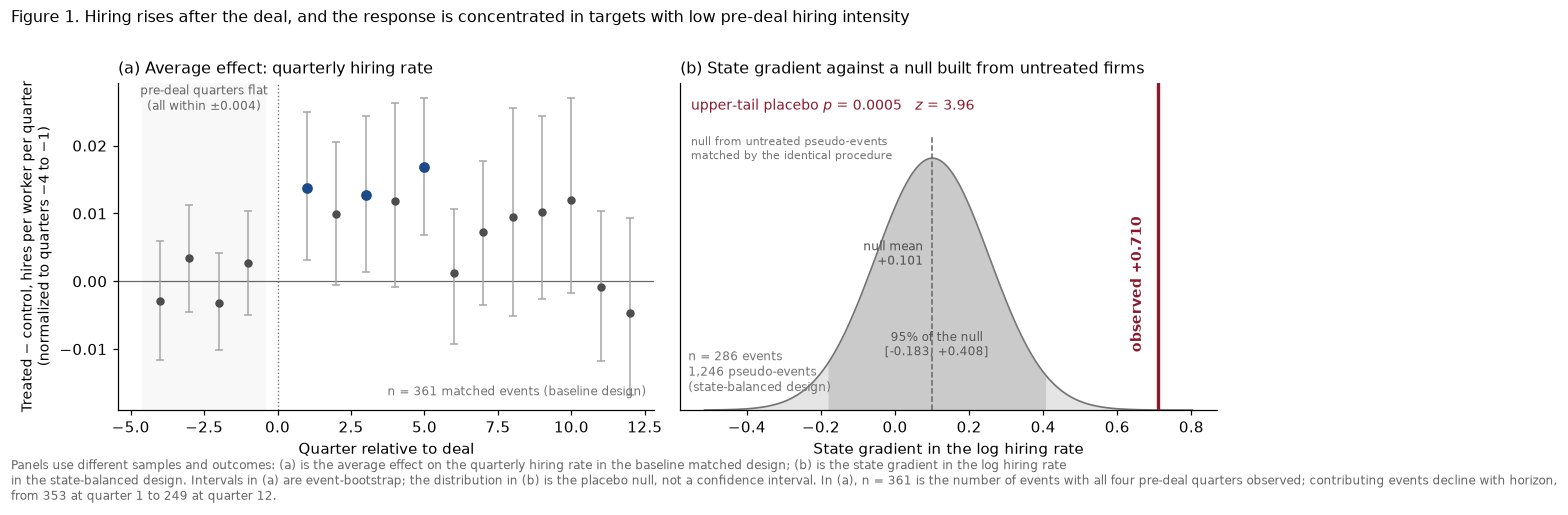

saved figure1_event_study.png / figure1_event_study.pdf


In [ ]:
# ════════════ Figure 2 — 이벤트스터디 + 조절/위약 ════════════
i32, i33, i35, i31, i68 = J("I32"), J("I33"), J("I35"), J("I31"), J("I68")
B = i68["estimates"]["beta"]
QL = [f"q{k}" for k in range(-4, 0)] + [f"q{k}" for k in range(1, 13)]
xs = list(range(-4, 0)) + list(range(1, 13))
b = [B[q]["b"] for q in QL]; lo = [B[q]["ci"][0] for q in QL]; hi = [B[q]["ci"][1] for q in QL]
sig = [B[q]["sig"] for q in QL]
SB = i35["estimates"]["canonical"]["C1_samebin"]; PL = i31["estimates"]["panelA_conditional_placebo"]
fig, ax = plt.subplots(1, 2, figsize=(11.2, 4.2))
a0 = ax[0]
a0.axhline(0, color="0.4", lw=.8); a0.axvline(0, color="0.45", lw=.9, ls=":")
a0.axvspan(-4.6, -0.4, color="0.5", alpha=.05, lw=0, zorder=0)
a0.errorbar(xs, b, yerr=[np.array(b)-np.array(lo), np.array(hi)-np.array(b)], fmt="o", ms=4.5,
            lw=1, capsize=2.5, color="0.3", ecolor="0.65", zorder=3)
a0.scatter([x for x, s in zip(xs, sig) if s], [v for v, s in zip(b, sig) if s], s=36,
           color="#1b4a8a", zorder=5)
a0.annotate("pre-deal quarters flat\n(all within ±0.004)", xy=(-2.5, max(hi[:4]) * 1.9 + 0.004),
            fontsize=8, color="0.4", ha="center")
a0.set_title("(a) Average effect: quarterly hiring rate", fontsize=10.5, loc="left")
a0.set_ylabel("Treated − control, hires per worker per quarter\n(normalized to quarters −4 to −1)", fontsize=9)
a0.set_xlabel("Quarter relative to deal")
a0.text(.985, .045, f"n = {i68['estimates']['n_ev']} matched events (baseline design)",
        transform=a0.transAxes, ha="right", fontsize=8, color="0.45")
a1 = ax[1]
i53 = J("I60")["estimates"]["specs"]["winsor_5_95"]
# 귀무분포를 정규 근사로 그린다 — draw 원자료는 저장하지 않으므로 평균·SD·95% 범위로 재구성
mu, sd = i53["null_mean"], i53["null_sd"]
lo, hi = i53["null_ci"]
xs = np.linspace(mu - 4 * sd, max(mu + 4 * sd, i53["observed"] + 0.6 * sd), 400)
dens = np.exp(-0.5 * ((xs - mu) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))
a1.fill_between(xs, dens, color="0.55", alpha=.22, lw=0, zorder=0)
a1.plot(xs, dens, color="0.45", lw=1.1, zorder=1)
inb = (xs >= lo) & (xs <= hi)
a1.fill_between(xs[inb], dens[inb], color="0.55", alpha=.30, lw=0, zorder=1)
a1.axvline(mu, color="0.4", lw=1, ls="--", zorder=2, ymax=.84)
a1.axvline(i53["observed"], color="#8a1b2e", lw=2.2, zorder=4)
ytop = dens.max()
a1.annotate(f"observed {i53['observed']:+.3f}", xy=(i53["observed"], ytop * .50),
            xytext=(-9, 0), textcoords="offset points", fontsize=9.4, color="#8a1b2e",
            weight="bold", va="center", ha="right", rotation=90)
a1.annotate(f"null mean\n{mu:+.3f}", xy=(mu, ytop * .62), xytext=(-6, 0),
            textcoords="offset points", fontsize=7.8, color="0.3", ha="right", va="center")
a1.annotate(f"95% of the null\n[{lo:+.3f}, {hi:+.3f}]", xy=((lo + hi) / 2, ytop * .26),
            fontsize=7.8, color="0.35", ha="center", va="center")
a1.text(.02, .95, f"upper-tail placebo $p$ = {i53['RI_p']:.4f}   $z$ = {i53['z']}",
        transform=a1.transAxes, ha="left", va="top", fontsize=9.2, color="#8a1b2e")
a1.text(.02, .84, "null from untreated pseudo-events\nmatched by the identical procedure",
        transform=a1.transAxes, ha="left", va="top", fontsize=7.4, color="0.45")
a1.set_yticks([])
a1.set_xlabel("State gradient in the log hiring rate")
a1.set_title("(b) State gradient against a null built from untreated firms",
             fontsize=10.5, loc="left")
a1.text(.015, .045, "n = 286 events\n1,246 pseudo-events\n(state-balanced design)",
        transform=a1.transAxes, ha="left", va="bottom", fontsize=8, color="0.45")
a1.set_ylim(0, ytop * 1.30)
for a in ax: a.spines[["top", "right"]].set_visible(False)
fig.suptitle("Figure 1. Hiring rises after the deal, and the response is concentrated in targets "
             "with low pre-deal hiring intensity", fontsize=10.2, y=1.005, x=.008, ha="left")
fig.text(.008, -0.055, "Panels use different samples and outcomes: (a) is the average effect on the "
         "quarterly hiring rate in the baseline matched design; (b) is the state gradient in the "
         "log hiring rate\nin the state-balanced design. Intervals in (a) are event-bootstrap; "
         "the distribution in (b) is the placebo null, not a confidence interval. "
         f"In (a), n = {i68['estimates']['n_ev']} is the number of events with all four pre-deal quarters observed; "
         f"contributing events decline with horizon,\nfrom {i68['estimates']['beta']['q1']['n']} at quarter 1 to "
         f"{i68['estimates']['beta']['q12']['n']} at quarter 12.",
         fontsize=7.6, color="0.4", ha="left")
fig.tight_layout(); SAVE(fig, "figure1_event_study"); plt.close(fig); print("saved figure1_event_study.png / figure1_event_study.pdf")


## Figure 2 — The hiring response is not matched by net employment growth


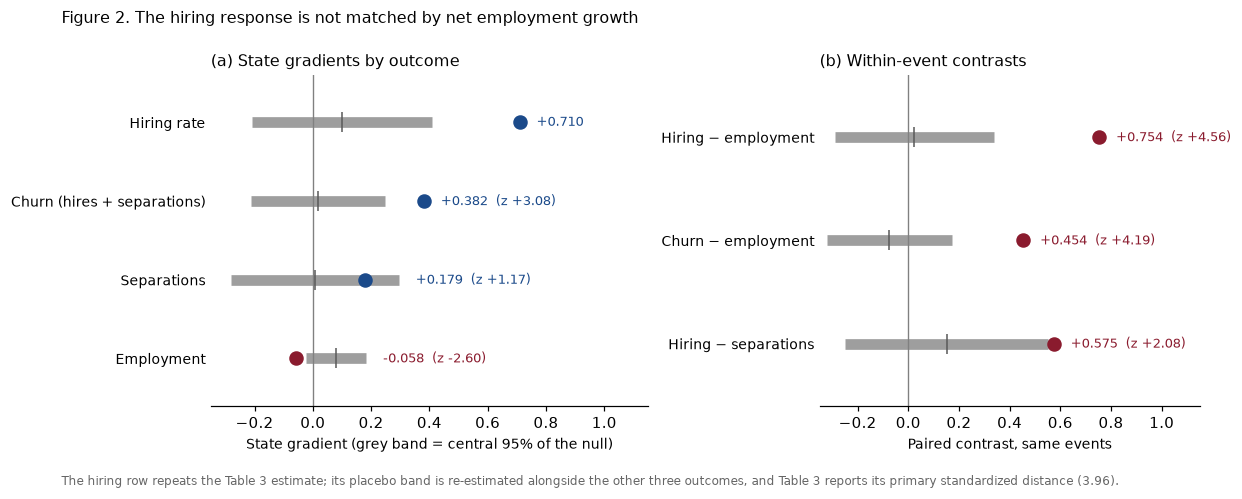

saved figure2_turnover.png / figure2_turnover.pdf


In [ ]:
# ════════════ Figure 5 — 정체가 성장이 아니라 순환으로 ════════════
i57 = J("I57")["estimates"]
PBo, PCo = i57["panelB_outcomes"], i57["panelC_paired"]
ROWS5 = [("Hiring rate", PBo["hire"], 0), ("Churn (hires + separations)", PBo["churn"], 0),
         ("Separations", PBo["sep"], 0), ("Employment", PBo["emp"], 1)]
PAIR = [("Hiring − employment", PCo["채용 − 고용"]), ("Churn − employment", PCo["churn − 고용"]),
        ("Hiring − separations", PCo["채용 − 이직"])]
fig, ax = plt.subplots(1, 2, figsize=(11.6, 3.9),
                       gridspec_kw={"width_ratios": [1.15, 1], "wspace": .42})
a0 = ax[0]
a0.axvline(0, color="0.5", lw=.9)
for i, (lab, r, flip) in enumerate(ROWS5):
    y = len(ROWS5) - 1 - i
    mu, sd, obs = r["null_mean"], r["null_sd"], r["observed"]
    col = "#8a1b2e" if flip else "#1b4a8a"
    a0.plot([mu - 1.96 * sd, mu + 1.96 * sd], [y, y], color="0.62", lw=7,
            solid_capstyle="butt", zorder=1)
    a0.plot([mu], [y], "|", ms=13, color="0.35", zorder=2)
    a0.plot([obs], [y], "o", ms=8.5, color=col, zorder=4)
    xa = max(obs, mu + 1.96 * sd)          # 점이 귀무 띠 안이면 띠 밖으로 밀어 겹침 방지
    a0.annotate(f"{obs:+.3f}" if lab.startswith("Hiring") else f"{obs:+.3f}  (z {r['z']:+.2f})",   # hiring z lives in Table 3
                xy=(xa, y), xytext=(11, 0),
                textcoords="offset points", va="center", fontsize=8.4, color=col)
a0.set_yticks(range(len(ROWS5)))
a0.set_yticklabels([r[0] for r in ROWS5][::-1], fontsize=9)
a0.set_xlim(-0.35, 1.15); a0.set_ylim(-0.6, len(ROWS5) - 0.4)
a0.set_xlabel("State gradient (grey band = central 95% of the null)", fontsize=9)
a0.set_title("(a) State gradients by outcome", fontsize=10.4, loc="left")
a0.spines[["top", "right", "left"]].set_visible(False); a0.tick_params(axis="y", length=0)
a1 = ax[1]
a1.axvline(0, color="0.5", lw=.9)
for i, (lab, r) in enumerate(PAIR):
    y = len(PAIR) - 1 - i
    mu, sd, obs = r["null_mean"], r["null_sd"], r["observed"]
    a1.plot([mu - 1.96 * sd, mu + 1.96 * sd], [y, y], color="0.62", lw=7,
            solid_capstyle="butt", zorder=1)
    a1.plot([mu], [y], "|", ms=13, color="0.35", zorder=2)
    a1.plot([obs], [y], "o", ms=8.5, color="#8a1b2e", zorder=4)
    xa = max(obs, mu + 1.96 * sd)
    a1.annotate(f"{obs:+.3f}  (z {r['z']:+.2f})", xy=(xa, y), xytext=(11, 0),
                textcoords="offset points", va="center", fontsize=8.4, color="#8a1b2e")
a1.set_yticks(range(len(PAIR)))
a1.set_yticklabels([r[0] for r in PAIR][::-1], fontsize=9)
a1.set_xlim(-0.35, 1.15); a1.set_ylim(-0.6, len(PAIR) - 0.4)
a1.set_xlabel("Paired contrast, same events", fontsize=9)
a1.set_title("(b) Within-event contrasts", fontsize=10.4, loc="left")
a1.spines[["top", "right", "left"]].set_visible(False); a1.tick_params(axis="y", length=0)
fig.suptitle("Figure 2. The hiring response is not matched by net employment growth",
             fontsize=10.2, y=1.03, x=.008, ha="left")
fig.text(.008, -0.075, "The hiring row repeats the Table 3 estimate; its placebo band is re-estimated alongside the other three outcomes, "
         "and Table 3 reports its primary standardized distance (3.96).", fontsize=7.6, color="0.4", ha="left")
SAVE(fig, "figure2_turnover"); plt.close(fig); print("saved figure2_turnover.png / figure2_turnover.pdf")


## Figure 3 — Pre-deal hiring state produces the clearest detectable heterogeneity


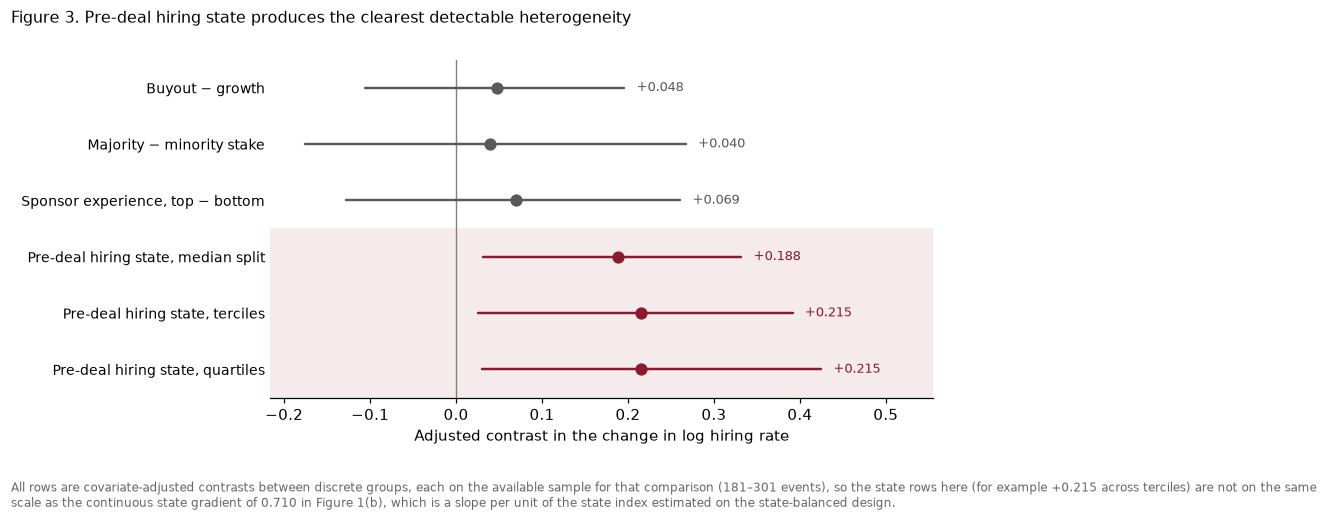

saved figure3_what_predicts.png / figure3_what_predicts.pdf


In [ ]:
# ════════════ Figure 3 — 무엇이 반응을 예측하는가 (조정 대비) ════════════
i45 = J("I45")["estimates"]["panelB_covariate_adjusted"]
i47 = J("I47")["estimates"]["panelA_fwl_adjusted"]["neg_log_rate"]
ROWS = [
 ("Buyout − growth", i45["deal_type"]["adjusted"]["diff"], i45["deal_type"]["adjusted"]["ci"], 0),
 ("Majority − minority stake", i45["stake_maj_min"]["adjusted"]["diff"],
  i45["stake_maj_min"]["adjusted"]["ci"], 0),
 ("Sponsor experience, top − bottom", i45["gp_experience"]["adjusted"]["diff"],
  i45["gp_experience"]["adjusted"]["ci"], 0),
 ("Pre-deal hiring state, median split", i47["median_adj"]["diff"], i47["median_adj"]["ci"], 1),
 ("Pre-deal hiring state, terciles", i47["tercile_adj"]["diff"], i47["tercile_adj"]["ci"], 1),
 ("Pre-deal hiring state, quartiles", i47["quartile_adj"]["diff"], i47["quartile_adj"]["ci"], 1),
]
fig, a = plt.subplots(figsize=(8.6, 4.1))
a.axvline(0, color="0.5", lw=.9)
for i, (lab, e, ci, star) in enumerate(ROWS):
    y = len(ROWS) - 1 - i
    col = "#8a1b2e" if star else "0.35"
    a.plot([ci[0], ci[1]], [y, y], color=col, lw=1.6, solid_capstyle="round")
    a.plot([e], [y], "o", ms=7, color=col, zorder=3)
    a.annotate(f"{e:+.3f}", xy=(ci[1], y), xytext=(8, 0), textcoords="offset points",
               va="center", fontsize=8.4, color=col)
a.set_yticks(range(len(ROWS)))
a.set_yticklabels([r[0] for r in ROWS][::-1], fontsize=9)
a.set_xlabel("Adjusted contrast in the change in log hiring rate", fontsize=9.5)
a.axhspan(-0.5, 2.5, color="#f5eaec", zorder=0)
a.set_ylim(-0.5, len(ROWS) - 0.5)
a.spines[["top", "right", "left"]].set_visible(False)
a.tick_params(axis="y", length=0)
xhi = max(ci[1] for _, _, ci, _ in ROWS)
xlo = min(ci[0] for _, _, ci, _ in ROWS)
a.set_xlim(xlo - 0.04, xhi + 0.13)
fig.suptitle("Figure 3. Pre-deal hiring state produces the clearest detectable heterogeneity",
             fontsize=10.2, y=1.0, x=.008, ha="left")
fig.text(.008, -0.10, "All rows are covariate-adjusted contrasts between discrete groups, each on the available sample for that "
         "comparison (181–301 events), so the state rows here (for example +0.215 across terciles) are not on the same\nscale "
         "as the continuous state gradient of 0.710 in Figure 1(b), which is a slope per unit of the "
         "state index estimated on the state-balanced design.", fontsize=7.6, color="0.4", ha="left")
fig.tight_layout(); SAVE(fig, "figure3_what_predicts"); plt.close(fig); print("saved figure3_what_predicts.png / figure3_what_predicts.pdf")


## Figure 4 — Changes in monthly hiring patterns are largely accounted for by a volume-only benchmark


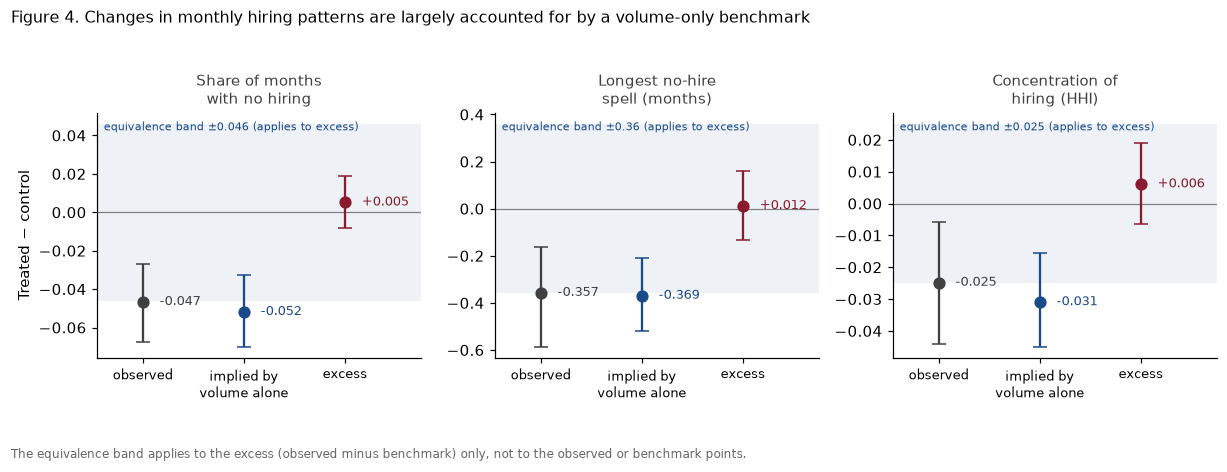

saved figure4_volume_benchmark.png / figure4_volume_benchmark.pdf


In [ ]:
# ════════════ Figure 4 — 총량 벤치마크 ════════════
i38, i39 = J("I38")["estimates"], J("I39")["estimates"]
ITEMS = [
 ("Share of months\nwith no hiring", i38["panelA_excess"]["actual"], i38["panelA_excess"]["expected_uniform"],
  i38["panelA_excess"]["excess_uniform"], 0.046),
 ("Longest no-hire\nspell (months)", i39["ms"]["actual"], i39["ms"]["expected"], i39["ms"]["excess"], 0.36),
 ("Concentration of\nhiring (HHI)", i39["hhi"]["actual"], i39["hhi"]["expected"], i39["hhi"]["excess"], 0.025),
]
fig, ax = plt.subplots(1, 3, figsize=(11.2, 3.6))
for a, (lab, act, exp, exc, d) in zip(ax, ITEMS):
    a.axhline(0, color="0.5", lw=.8)
    a.axhspan(-d, d, color="#1b4a8a", alpha=.07, lw=0, zorder=0)
    for i, (nm, r, col) in enumerate([("observed", act, "0.25"),
                                      ("implied by\nvolume alone", exp, "#1b4a8a"),
                                      ("excess", exc, "#8a1b2e")]):
        e, ci = r["DiD"], r["ci"]
        a.errorbar([i], [e], yerr=[[e - ci[0]], [ci[1] - e]], fmt="o", ms=7, lw=1.5,
                   capsize=4.5, color=col, ecolor=col)
        a.annotate(f"{e:+.3f}", xy=(i, e), xytext=(11, 0), textcoords="offset points",
                   ha="left", va="center", fontsize=8.2, color=col)
    a.set_xticks([0, 1, 2])
    a.set_xticklabels(["observed", "implied by\nvolume alone", "excess"], fontsize=8.4)
    a.set_xlim(-.45, 2.75)
    a.set_title(lab, fontsize=9.8, color="0.25")
    a.spines[["top", "right"]].set_visible(False)
    a.text(.02, .965, f"equivalence band ±{d:g} (applies to excess)", transform=a.transAxes,
           ha="left", va="top", fontsize=7.2, color="#1b4a8a")
ax[0].set_ylabel("Treated − control", fontsize=9.5)
fig.suptitle("Figure 4. Changes in monthly hiring patterns are largely accounted for by a volume-only benchmark", fontsize=10.4, y=1.03, x=.008, ha="left")
fig.text(.008, -0.10, "The equivalence band applies to the excess (observed minus benchmark) only, not to "
         "the observed or benchmark points.", fontsize=7.6, color="0.4", ha="left")
fig.tight_layout(); SAVE(fig, "figure4_volume_benchmark"); plt.close(fig); print("saved figure4_volume_benchmark.png / figure4_volume_benchmark.pdf")


## Appendix Figure A1 — Monthly no-hire measures attenuate under temporal aggregation


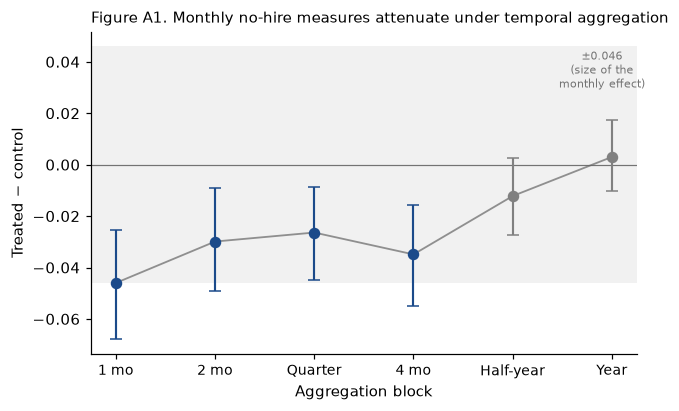

saved figureA1_aggregation.png / figureA1_aggregation.pdf


In [ ]:
# ════════════ Appendix Figure A1 — 집계주기 감쇠 ════════════
A = J("I01")["estimates"]["panelA_inaction_by_block"]
ks = ["1", "2", "3", "4", "6", "12"]; labs = ["1 mo", "2 mo", "Quarter", "4 mo", "Half-year", "Year"]
v = [A[k]["DiD"] for k in ks]; ci = [A[k]["ci"] for k in ks]; sg = [A[k]["sig"] for k in ks]
fig, a = plt.subplots(figsize=(6.4, 3.8))
a.axhline(0, color="0.45", lw=.8)
a.axhspan(-0.046, 0.046, color="0.6", alpha=.13, lw=0)
for i, (e, cc, s) in enumerate(zip(v, ci, sg)):
    col = "#1b4a8a" if s else "0.5"
    a.errorbar([i], [e], yerr=[[e-cc[0]], [cc[1]-e]], fmt="o", ms=6.5, lw=1.4, capsize=4, color=col, ecolor=col)
a.plot(range(len(v)), v, "-", lw=1.2, color="0.4", alpha=.7)
a.set_xticks(range(len(labs))); a.set_xticklabels(labs, fontsize=9)
a.set_ylabel("Treated − control"); a.set_xlabel("Aggregation block")
a.text(4.9, .030, "±0.046\n(size of the\nmonthly effect)", fontsize=7.4, color="0.45", ha="center")
a.spines[["top", "right"]].set_visible(False)
a.set_title("Figure A1. Monthly no-hire measures attenuate under temporal aggregation", fontsize=10, loc="left")
SAVE(fig, "figureA1_aggregation"); plt.close(fig); print("saved figureA1_aggregation.png / figureA1_aggregation.pdf")


## Appendix Figure A2 — Where this paper sits


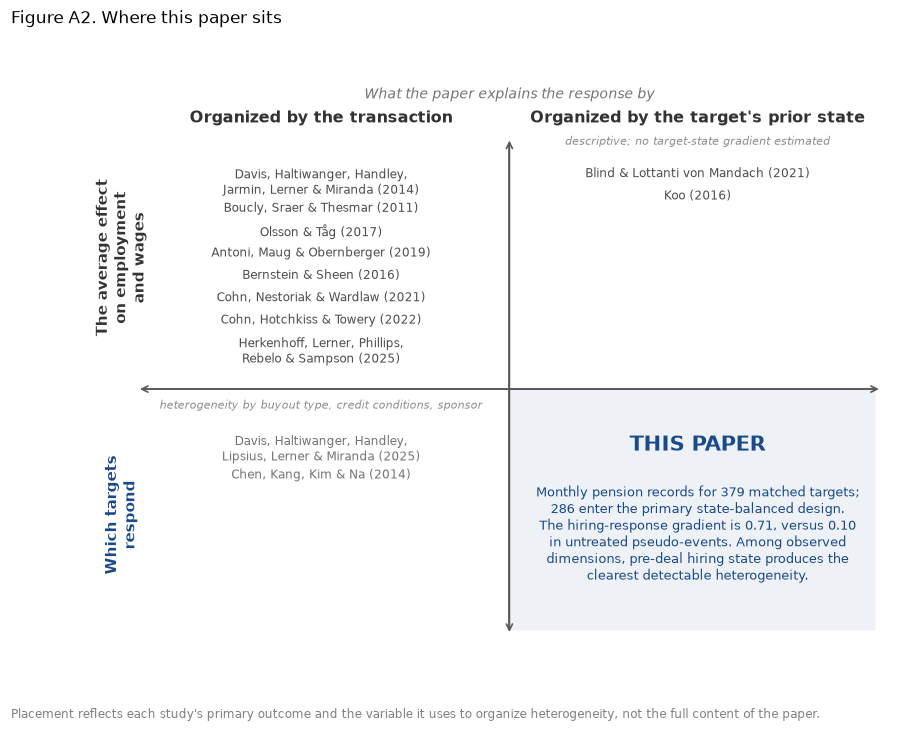

saved figureA2_positioning.png / figureA2_positioning.pdf


In [ ]:
# ════════════ Figure 1 — 2×2 포지셔닝 ════════════
fig, ax = plt.subplots(figsize=(9.2, 6.6))
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")
ax.add_patch(FancyBboxPatch((5.02, 0.35), 4.63, 4.3, boxstyle="round,pad=0.02",
                            fc="#1b4a8a", alpha=.07, ec="none", zorder=0))
ax.plot([5, 5], [0.35, 9.0], color="0.35", lw=1.1)
ax.plot([0.35, 9.65], [4.65, 4.65], color="0.35", lw=1.1)
ax.annotate("", xy=(9.75, 4.65), xytext=(0.25, 4.65), arrowprops=dict(arrowstyle="<->", color="0.35", lw=1.1))
ax.annotate("", xy=(5, 9.15), xytext=(5, 0.25), arrowprops=dict(arrowstyle="<->", color="0.35", lw=1.1))
ax.text(2.6, 9.42, "Organized by the transaction", ha="center", fontsize=10.5, weight="bold", color="0.2")
ax.text(7.4, 9.42, "Organized by the target's prior state", ha="center", fontsize=10.5, weight="bold", color="0.2")
ax.text(0.05, 7.0, "The average effect\non employment\nand wages", rotation=90, va="center",
        ha="center", fontsize=10, weight="bold", color="0.2")
ax.text(0.05, 2.4, "Which targets\nrespond", rotation=90, va="center",
        ha="center", fontsize=10, weight="bold", color="#1b4a8a")
ax.text(5, 9.85, "What the paper explains the response by", ha="center", fontsize=9, color="0.45", style="italic")
TL = ["Davis, Haltiwanger, Handley,\nJarmin, Lerner & Miranda (2014)",
      "Boucly, Sraer & Thesmar (2011)", "Olsson & Tåg (2017)",
      "Antoni, Maug & Obernberger (2019)", "Bernstein & Sheen (2016)",
      "Cohn, Nestoriak & Wardlaw (2021)", "Cohn, Hotchkiss & Towery (2022)",
      "Herkenhoff, Lerner, Phillips,\nRebelo & Sampson (2025)"]
TR = ["Blind & Lottanti von Mandach (2021)", "Koo (2016)"]
BL = ["Davis, Haltiwanger, Handley,\nLipsius, Lerner & Miranda (2025)",
      "Chen, Kang, Kim & Na (2014)"]
y = 8.62
for t in TL: ax.text(2.6, y, t, ha="center", va="top", fontsize=7.9, color="0.3"); y -= (0.62 if "\n" in t else 0.40)
y = 8.62
ax.text(7.4, y + 0.40, "descriptive; no target-state gradient estimated", ha="center", fontsize=7.4,
        color="0.55", style="italic")
for t in TR: ax.text(7.4, y, t, ha="center", va="top", fontsize=7.9, color="0.3"); y -= (0.62 if "\n" in t else 0.40)
y = 3.85
ax.text(2.6, 4.30, "heterogeneity by buyout type, credit conditions, sponsor", ha="center",
        fontsize=7.4, color="0.55", style="italic")
for t in BL: ax.text(2.6, y, t, ha="center", va="top", fontsize=7.9, color="0.45"); y -= (0.62 if "\n" in t else 0.40)
ax.text(7.4, 3.55, "THIS PAPER", ha="center", fontsize=13.5, weight="bold", color="#1b4a8a")
ax.text(7.4, 2.95, "Monthly pension records for 379 matched targets;\n286 enter the primary state-balanced design.\n"
                   "The hiring-response gradient is 0.71, versus 0.10\nin untreated pseudo-events. Among observed\n"
                   "dimensions, pre-deal hiring state produces the\nclearest detectable heterogeneity.",
        ha="center", va="top", fontsize=8.4, color="#1b4a8a")
fig.suptitle("Figure A2. Where this paper sits", fontsize=11, x=.02, ha="left", y=.99)
fig.text(.02, .015, "Placement reflects each study's primary outcome and the variable it uses to "
                    "organize heterogeneity, not the full content of the paper.", fontsize=7.6, color="0.5")
SAVE(fig, "figureA2_positioning"); plt.close(fig); print("saved figureA2_positioning.png / figureA2_positioning.pdf")


## Consistency check — regenerated figures versus the paper's figure files
SHA-256 of each PNG just written to `../figures/` against the file attached to the manuscript in `../paper_exhibits/figures/`.


In [ ]:
import hashlib
def sha(p): return hashlib.sha256(open(p, "rb").read()).hexdigest()
fails = 0
for n in ["figure1_event_study", "figure2_turnover", "figure3_what_predicts", "figure4_volume_benchmark", "figureA1_aggregation", "figureA2_positioning"]:
    a, b = sha(f"../figures/{n}.png"), sha(f"../paper_exhibits/figures/{n}.png")
    ok = a == b; fails += (not ok); print(f"{n:<28} {'IDENTICAL' if ok else 'DIFFERS'}  sha256 {a[:16]}")
assert fails == 0, f"{fails} figure(s) differ from the paper"
print("\nAll 6 figures are byte-identical to the paper's figure files.")


figure1_event_study          IDENTICAL  sha256 a936d4f9b939ab87
figure2_turnover             IDENTICAL  sha256 20fc0a5099867c85
figure3_what_predicts        IDENTICAL  sha256 22bf7454d319d4f7
figure4_volume_benchmark     IDENTICAL  sha256 5121293b707dc2dc
figureA1_aggregation         IDENTICAL  sha256 2a59eb864d7d93b8
figureA2_positioning         IDENTICAL  sha256 a22564efa8542e54

All 6 figures are byte-identical to the paper's figure files.
